In [2]:
import torch
device= torch.device("cuda"if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# imports and requirements
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# it open file picker  in Browser
# we select file from pc and it comes in colab inviroment

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"surendrak21","key":"d9a362405b70ebdd044158f29c5248b3"}'}

In [5]:
# make directory in colab home and move kaggle.json in it
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
# download tumor dataset  , it download a zip file
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
  0% 0.00/149M [00:00<?, ?B/s]
100% 149M/149M [00:00<00:00, 1.58GB/s]


In [7]:
# unzip dataset
!unzip brain-tumor-mri-dataset.zip


Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_0712.jpg  
  inflating: Training/glioma/Tr-gl_0713.jpg  
  inflating: Training/glioma/Tr-gl_0714.jpg  
  inflating: Training/glioma/Tr-gl_0715.jpg  
  inflating: Training/glioma/Tr-gl_0716.jpg  
  inflating: Training/glioma/Tr-gl_0717.jpg  
  inflating: Training/glioma/Tr-gl_0718.jpg  
  inflating: Training/glioma/Tr-gl_0719.jpg  
  inflating: Training/glioma/Tr-gl_0720.jpg  
  inflating: Training/glioma/Tr-gl_0721.jpg  
  inflating: Training/glioma/Tr-gl_0722.jpg  
  inflating: Training/glioma/Tr-gl_0723.jpg  
  inflating: Training/glioma/Tr-gl_0724.jpg  
  inflating: Training/glioma/Tr-gl_0725.jpg  
  inflating: Training/glioma/Tr-gl_0726.jpg  
  inflating: Training/glioma/Tr-gl_0727.jpg  
  inflating: Training/glioma/Tr-gl_0728.jpg  
  inflating: Training/glioma/Tr-gl_0729.jpg  
  inflating: Training/glioma/Tr-gl_0730.jpg  
  inflating: Training/glioma/Tr-gl_0731.jpg  
  inflating: Training/glioma/

In [8]:
!ls

brain-tumor-mri-dataset.zip  sample_data  Testing  Training


In [9]:
!ls Training


glioma	meningioma  notumor  pituitary


In [10]:
from torchvision import datasets  # to load data from memory
from torch.utils.data import DataLoader # to makes batches of data
from torchvision import transforms # to tranform data

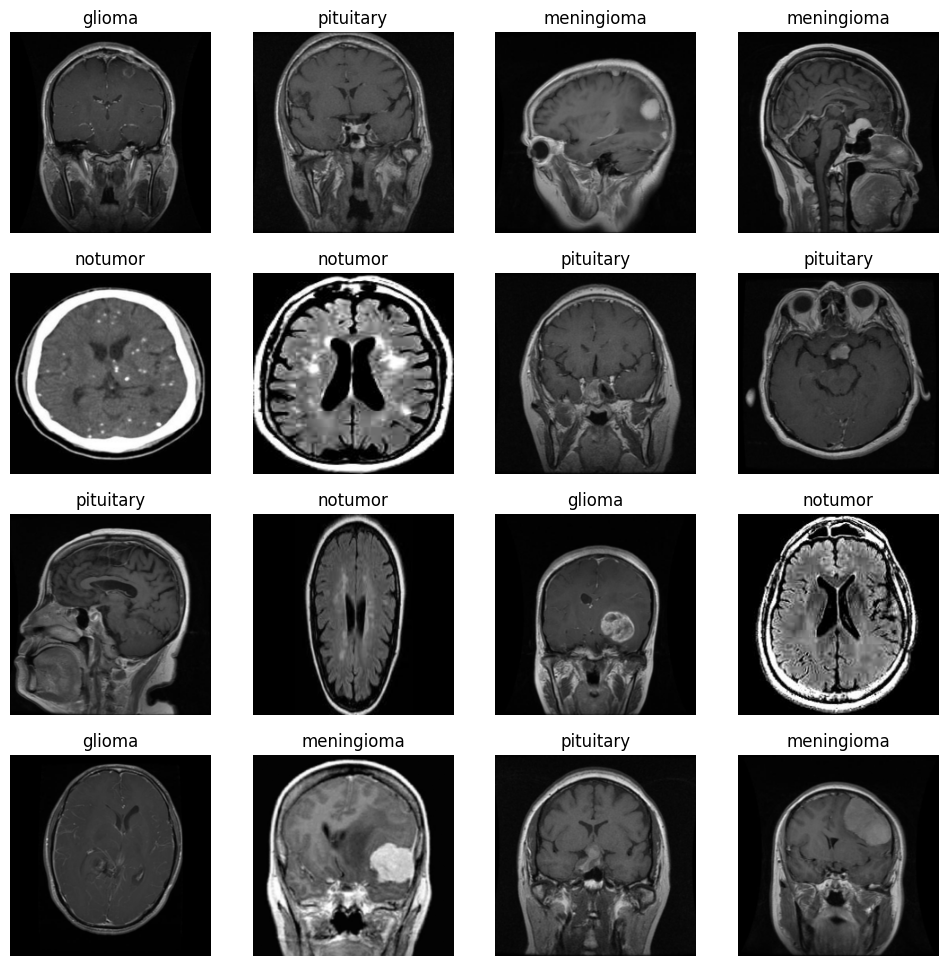

In [11]:
# raw data to inspect data
raw_transform = transforms.Compose([   # to compose all transform
    transforms.Resize((224, 224)),     #  to convert image in fixed size (224×224) as ResNet50  expect 224×224 input
    transforms.ToTensor()   # to change PIL Image / JPEG / PNG into Pytoch image sybtex
])


raw_data = datasets.ImageFolder(   # read all images from Training folder and level them as their folder name
    root='Training',
    transform=raw_transform   # apply raw_transform
)

raw_loader = DataLoader(raw_data, batch_size=16 , shuffle=True)  # bring images from raw_data  in 16 batch size in random order
images, labels = next(iter(raw_loader)) # extract images and labels

# print images

plt.figure(figsize=(12,12))

for i in range(16):
    plt.subplot(4,4,i+1)
    img = images[i].permute(1, 2, 0)  # C,H,W → H,W,C
    plt.imshow(img)
    plt.title(raw_data.classes[labels[i]])
    plt.axis("off")

plt.show()


In [12]:
# tranform datasets

img_size=224

# transform train data
train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),  #flip Image left-right  randomly for multiple variations of a image so model train better
        transforms.ToTensor(),
        transforms.Normalize(          #  normalized_pixel = (pixel - mean) / std
          mean=[0.485, 0.456, 0.406],   # ImageNet dataset values as ResNet50 pretrained on ImageNet
          std=[0.229, 0.224, 0.225]
    )
])


# transform test data
test_transform= transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [13]:
# load dataset

# train data
train_data = datasets.ImageFolder(
    root='Training',
    transform=train_transform
)

# test data
test_data = datasets.ImageFolder(
    root='Testing',
    transform=test_transform
)

train_loader = DataLoader(train_data , batch_size=16 , shuffle=True)  # train_loader to load train data
test_loader = DataLoader(test_data , batch_size=16 , shuffle=True)    # test_loader  to load test data

print(train_data.classes)   #  ['glioma', 'meningioma', 'notumor', 'pituitary']

['glioma', 'meningioma', 'notumor', 'pituitary']


In [14]:
from torchvision import models
import torch.nn as nn

model = models.resnet50(pretrained=True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


In [15]:
# freeze the pretrained backbone so that the learned feature representations remain unchanged,
# and I train only the final  classification layers for my specific dataset


for param in model.parameters():
    param.requires_grad=False     # every pretrained parameters (weights , bias etc) does not need to update

num_classes = 4   # dataset labels:  ['glioma', 'meningioma', 'notumor', 'pituitary']

# replace ResNet50's last fully connected layer
# Features → 2048 → 128 → 4

model.fc = nn.Sequential(
    nn.Dropout(0.5),       # close 50% neurons at training time
                           # so model avoid over learn and overfitting
    nn.Linear(model.fc.in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.25 ),    # little bit more regularization
    nn.Linear(128 , num_classes)
)

In [16]:
# connect model with gpu

model = model.to(device)


In [17]:
# final fully connected layer,
print(model.fc)

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=128, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.25, inplace=False)
  (4): Linear(in_features=128, out_features=4, bias=True)
)


In [18]:
# False prediction of model
# CrossEntropyLoss do two things apply CrossEntropyLoss (internally)
# and loss calculation of Correct class ( loss = -log(probability_of_true_class) )
criterion = nn.CrossEntropyLoss()

In [19]:
# optimize parameters
import torch.optim as optim

optimizer = optim.Adamax(
    model.parameters(),
    lr=0.001
)


In [20]:
num_epochs=10 # model look-up data 10 times

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# load validation data ,
val_loader = DataLoader(
    test_data,            # use test data for model validation
    batch_size=16,
    shuffle=False
)


for epoch in range(num_epochs):

    # model training
    model.train()
    running_loss=0.0
    correct = 0
    total=0

    for images , labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs , labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs , 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)


        # ===== VALIDATION =====
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():  # no need of grad as it is validation part
         for images , labels in val_loader:
             images = images.to(device)
             labels = labels.to(device)

             outputs = model(images)
             loss = criterion(outputs, labels)

             val_running_loss += loss.item()
             _, predicted = torch.max(outputs, 1)
             val_total += labels.size(0)
             val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%"
    )







Epoch [1/10] | Train Loss: 0.7056, Train Acc: 73.16% | Val Loss: 0.5246, Val Acc: 78.79%
Epoch [2/10] | Train Loss: 0.4885, Train Acc: 81.62% | Val Loss: 0.4195, Val Acc: 83.60%
Epoch [3/10] | Train Loss: 0.4698, Train Acc: 82.49% | Val Loss: 0.4357, Val Acc: 83.07%
Epoch [4/10] | Train Loss: 0.4421, Train Acc: 83.63% | Val Loss: 0.3778, Val Acc: 84.97%
Epoch [5/10] | Train Loss: 0.4117, Train Acc: 84.51% | Val Loss: 0.3696, Val Acc: 85.13%
Epoch [6/10] | Train Loss: 0.4094, Train Acc: 84.80% | Val Loss: 0.3857, Val Acc: 84.90%
Epoch [7/10] | Train Loss: 0.4092, Train Acc: 84.89% | Val Loss: 0.3560, Val Acc: 85.51%
Epoch [8/10] | Train Loss: 0.4013, Train Acc: 84.65% | Val Loss: 0.3611, Val Acc: 85.89%
Epoch [9/10] | Train Loss: 0.3908, Train Acc: 85.38% | Val Loss: 0.3340, Val Acc: 86.50%
Epoch [10/10] | Train Loss: 0.3961, Train Acc: 84.73% | Val Loss: 0.3300, Val Acc: 86.80%


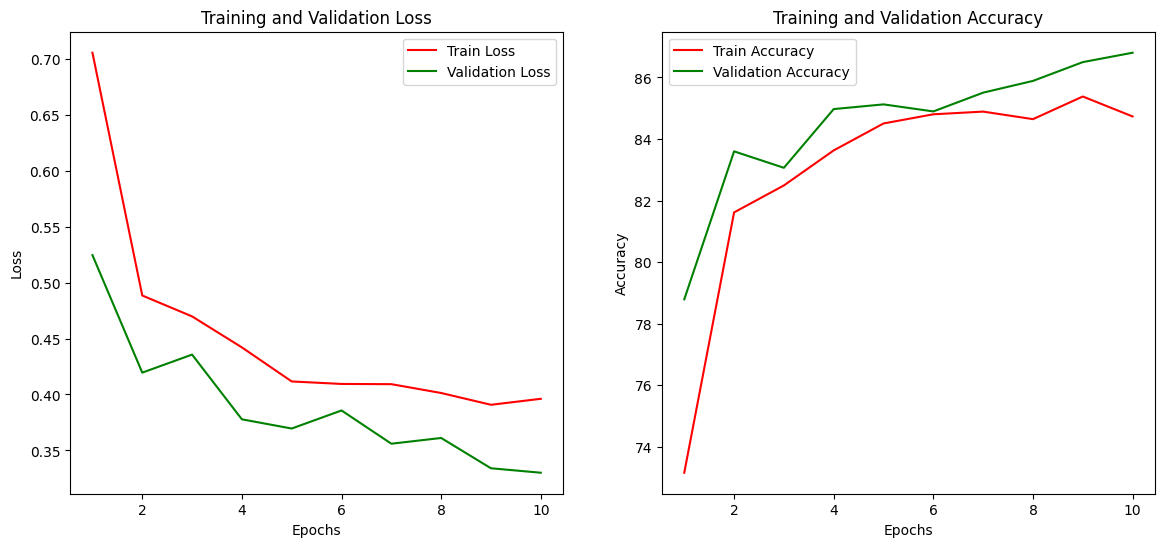

In [21]:
# GRAPHS

epochs = range(1, num_epochs + 1)



plt.figure(figsize=(14,6))

# 🔹 LOSS GRAPH
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, 'r-', label='Train Loss')
plt.plot(epochs, val_losses, 'g-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 🔹 ACCURACY GRAPH
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, 'r-', label='Train Accuracy')
plt.plot(epochs, val_accuracies, 'g-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


In [22]:
# evaluation of model

y_true = []  # actual value
y_pred = []  # predicted value by model

model.eval()  # start evaluation over test data
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())    # actual values list
        y_pred.extend(predicted.cpu().numpy()) # predicted values list




In [23]:
# print our classification


print(classification_report(
    y_true,
    y_pred,
    target_names=train_data.classes
))


              precision    recall  f1-score   support

      glioma       0.93      0.84      0.88       300
  meningioma       0.80      0.65      0.72       306
     notumor       0.87      0.97      0.92       405
   pituitary       0.87      0.98      0.92       300

    accuracy                           0.87      1311
   macro avg       0.87      0.86      0.86      1311
weighted avg       0.87      0.87      0.86      1311



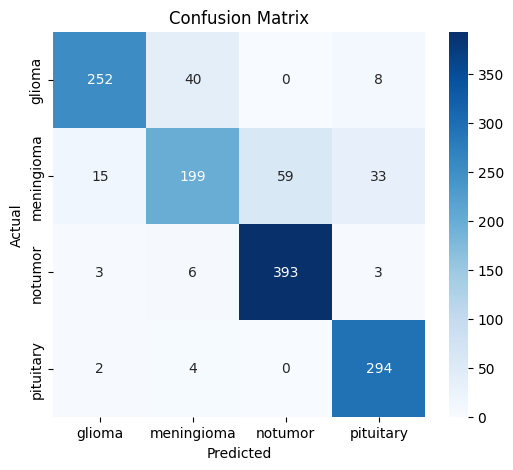

In [24]:
# confusion matrix



cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [25]:
# save model
torch.save(model.state_dict(), "tumor_resnet50.pth")
